# Part I: Final Data Preparation (15 points)
Prepare your cleaned dataset for machine learning.
Include:
- Final predictor variables
- Target variable
- Train/test split
- Stratification (when appropriate)
- Encoding
- Scaling or normalization (when appropriate)
- Machine learning pipeline implementation
- Explain each preprocessing decision.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TEST_SIZE = 0.20
FEATURES = [f"X{i}" for i in range(1, 17)]
TARGET = "y"
MULTICLASS_NAMES = {
    0: "Healthy",
    1: "Generalized seizure",
    2: "Focal seizure",
    3: "Seizure event",
}
BINARY_NAMES = {0: "Healthy", 1: "Seizure activity"}

#Locates the supplied CSV.
data_candidates = [
    Path("BEED_Data.csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place BEED_Data.csv in the same folder as this notebook.")

df = pd.read_csv(data_path)
expected_columns = FEATURES + [TARGET]
if list(df.columns) != expected_columns:
    raise ValueError(f"Expected columns {expected_columns}, but found {list(df.columns)}.")

#Validates the final data before any split or model fitting.
if df.isna().any().any():
    raise ValueError("Missing values were found; preprocessing must be reconsidered.")
if set(df[TARGET].unique()) != {0, 1, 2, 3}:
    raise ValueError("The target must contain the original labels 0, 1, 2, and 3.")

X = df[FEATURES].copy()
y_multiclass = df[TARGET].astype(int).copy()
y_binary = y_multiclass.ne(0).astype(int)

#Splits once with the original four classes so both formulations use identical rows.
row_ids = np.arange(len(df))
train_ids, test_ids = train_test_split(
    row_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_multiclass,
)
#Class tasks dictionary
tasks = {
    "Four-class": {
        "y": y_multiclass,
        "class_names": MULTICLASS_NAMES,
    },
    "Binary": {
        "y": y_binary,
        "class_names": BINARY_NAMES,
    },
}

split_rows = []
for task_name, task in tasks.items():
    for split_name, ids in [("Training", train_ids), ("Test", test_ids)]:
        counts = task["y"].iloc[ids].value_counts().sort_index()
        for label, count in counts.items():
            split_rows.append(
                {
                    "Target": task_name,
                    "Split": split_name,
                    "Class": task["class_names"][int(label)],
                    "Observations": int(count),
                }
            )

split_summary = pd.DataFrame(split_rows)
display(split_summary)

,Target,Split,Class,Observations
0,Four-class,Training,Healthy,1600
1,Four-class,Training,Generalized seizure,1600
2,Four-class,Training,Focal seizure,1600
3,Four-class,Training,Seizure event,1600
4,Four-class,Test,Healthy,400
5,Four-class,Test,Generalized seizure,400
6,Four-class,Test,Focal seizure,400
7,Four-class,Test,Seizure event,400
8,Binary,Training,Healthy,1600
9,Binary,Training,Seizure activity,4800


### Preprocessing decisions

- **Predictors:** All 16 numeric EEG-channel variables (`X1`-`X16`) are retained. EDA did not justify removing any channel.
- **Targets:** The four-class target keeps `0 = Healthy`, `1 = Generalized seizure`, `2 = Focal seizure`, and `3 = Seizure event`. The binary target keeps healthy as `0` and combines original classes `1`-`3` as `1 = Seizure activity`.
- **Train/test split:** The same stratified 80/20 split is used for both targets: 6,400 training observations and 1,600 untouched test observations. Stratifying on the original target preserves all four classes and therefore also preserves the binary ratio.
- **Encoding:** No predictor encoding is needed because every channel is numeric. The target labels are already integer class codes.
- **Missing values and duplicates:** EDA found no missing values or duplicate rows, so no imputation or row removal is performed.
- **Scaling:** Raw channel values are kept for Random Forest. Standardization is fitted only inside the Logistic Regression pipeline so each validation fold and the test set remain isolated from training statistics.
- **Pipelines:** Model-specific preprocessing and estimation are combined in scikit-learn pipelines. This prevents data leakage and keeps the binary and multiclass comparisons consistent.

# Part II: Baseline Model Development (25 points)
Train at least two supervised classification models, including one baseline model.
 Possible models include:
- Logistic Regression
- Decision Tree
- DummyClassifier
- k-Nearest Neighbors (kNN)
- Support Vector Machine (SVM)
- Random Forest
- For each model, explain why it was selected and discuss its expected strengths and limitations.



In [2]:
# Part II: Baseline Model Development
def make_models():
    
    #Returns fresh sklearn Pipeline objects for each target.
    #Creating new instances per-task ensures independent fitting and prevents
    #shared fitted scalers between different target formulations.

    return {
        "Dummy baseline": Pipeline([
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,  #Sufficient iterations for convergence
                class_weight="balanced",  #Mitigates binary class imbalance
                random_state=RANDOM_STATE,
            )),
        ]),
        "Random Forest": Pipeline([
            ("model", RandomForestClassifier(
                n_estimators=300,  #Sufficient depth for complex nonlinear patterns
                min_samples_leaf=2,  #Prevents severe overfitting while allowing flexibility
                max_features="sqrt",  #Reduces correlation among trees; n_features=16 → sqrt=4
                class_weight="balanced",  #Mitigates class imbalance
                random_state=RANDOM_STATE,
                n_jobs=-1,  #Parallelizes over all available cores
            )),
        ]),
    }


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
}

fitted_models = {}
development_rows = []

for task_name, task in tasks.items():
    X_train = X.iloc[train_ids]
    y_train = task["y"].iloc[train_ids]
    fitted_models[task_name] = {}

    for model_name, model in make_models().items():
        start = time.perf_counter()
        scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=1,
        )
        model.fit(X_train, y_train)
        #Elapsed time includes both cross-validation and final model fit on all training data.
        elapsed = time.perf_counter() - start
        fitted_models[task_name][model_name] = model

        development_rows.append({
            "Target": task_name,
            "Model": model_name,
            "CV accuracy": scores["test_accuracy"].mean(),
            "CV balanced accuracy": scores["test_balanced_accuracy"].mean(),
            "CV macro F1": scores["test_macro_f1"].mean(),
            "CV macro F1 SD": scores["test_macro_f1"].std(),
            "CV train macro F1": scores["train_macro_f1"].mean(),
            "CV + fit seconds": elapsed,
        })

development_results = pd.DataFrame(development_rows)
display(development_results.round({
    "CV accuracy": 3,
    "CV balanced accuracy": 3,
    "CV macro F1": 3,
    "CV macro F1 SD": 3,
    "CV train macro F1": 3,
    "CV + fit seconds": 2,
}))

,Target,Model,CV accuracy,CV balanced accuracy,CV macro F1,CV macro F1 SD,CV train macro F1,CV + fit seconds
0,Four-class,Dummy baseline,0.250,0.250,0.100,0.000,0.100,0.11
1,Four-class,Logistic Regression,0.472,0.472,0.477,0.009,0.488,0.34
2,Four-class,Random Forest,0.949,0.949,0.949,0.009,1.000,4.80
3,Binary,Dummy baseline,0.750,0.500,0.429,0.000,0.429,0.06
4,Binary,Logistic Regression,0.630,0.621,0.585,0.009,0.589,0.22
5,Binary,Random Forest,0.998,0.997,0.997,0.002,1.000,3.97


- **Dummy Classifier** is the no-skill baseline. It reveals how misleading raw accuracy can be: the binary majority class alone represents 75% of the observations, while each multiclass category represents 25%.
- **Logistic Regression** is a fast, interpretable linear baseline. It can show whether standardized channel combinations separate the classes with simple decision boundaries. Its main limitation is that nonlinear relationships and channel interactions may be missed; correlated predictors can also make individual coefficients unstable.
- **Random Forest** can learn nonlinear thresholds and interactions suggested by the EDA without requiring scaled predictors. It is less directly interpretable, takes longer to train, and can overfit if its trees are too flexible.

`class_weight="balanced"` is used for both trained models. It has little effect on the balanced four-class target but prevents the 75% seizure majority from dominating the binary objective. Hyperparameter tuning is postponed so these remain preliminary, comparable models.

# Part III: Preliminary Results & Evaluation (25 points)
Evaluate your models using appropriate performance metrics.
 Possible evaluation measures include:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC (when applicable)
- Macro or Weighted F1-score
- Balanced Accuracy
- Confusion Matrix
- Interpret what each metric tells you about model performance.

,Target,Model,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1,Weighted F1,ROC-AUC,Train macro F1
0,Four-class,Dummy baseline,0.250,0.250,0.062,0.250,0.100,0.100,0.500,0.100
1,Four-class,Logistic Regression,0.454,0.454,0.483,0.454,0.461,0.461,0.658,0.488
2,Four-class,Random Forest,0.958,0.958,0.958,0.958,0.958,0.958,0.997,1.000
3,Binary,Dummy baseline,0.750,0.500,0.375,0.500,0.429,0.643,0.500,0.429
4,Binary,Logistic Regression,0.615,0.605,0.580,0.605,0.570,0.640,0.651,0.589
5,Binary,Random Forest,0.999,0.998,0.999,0.998,0.998,0.999,1.000,1.000


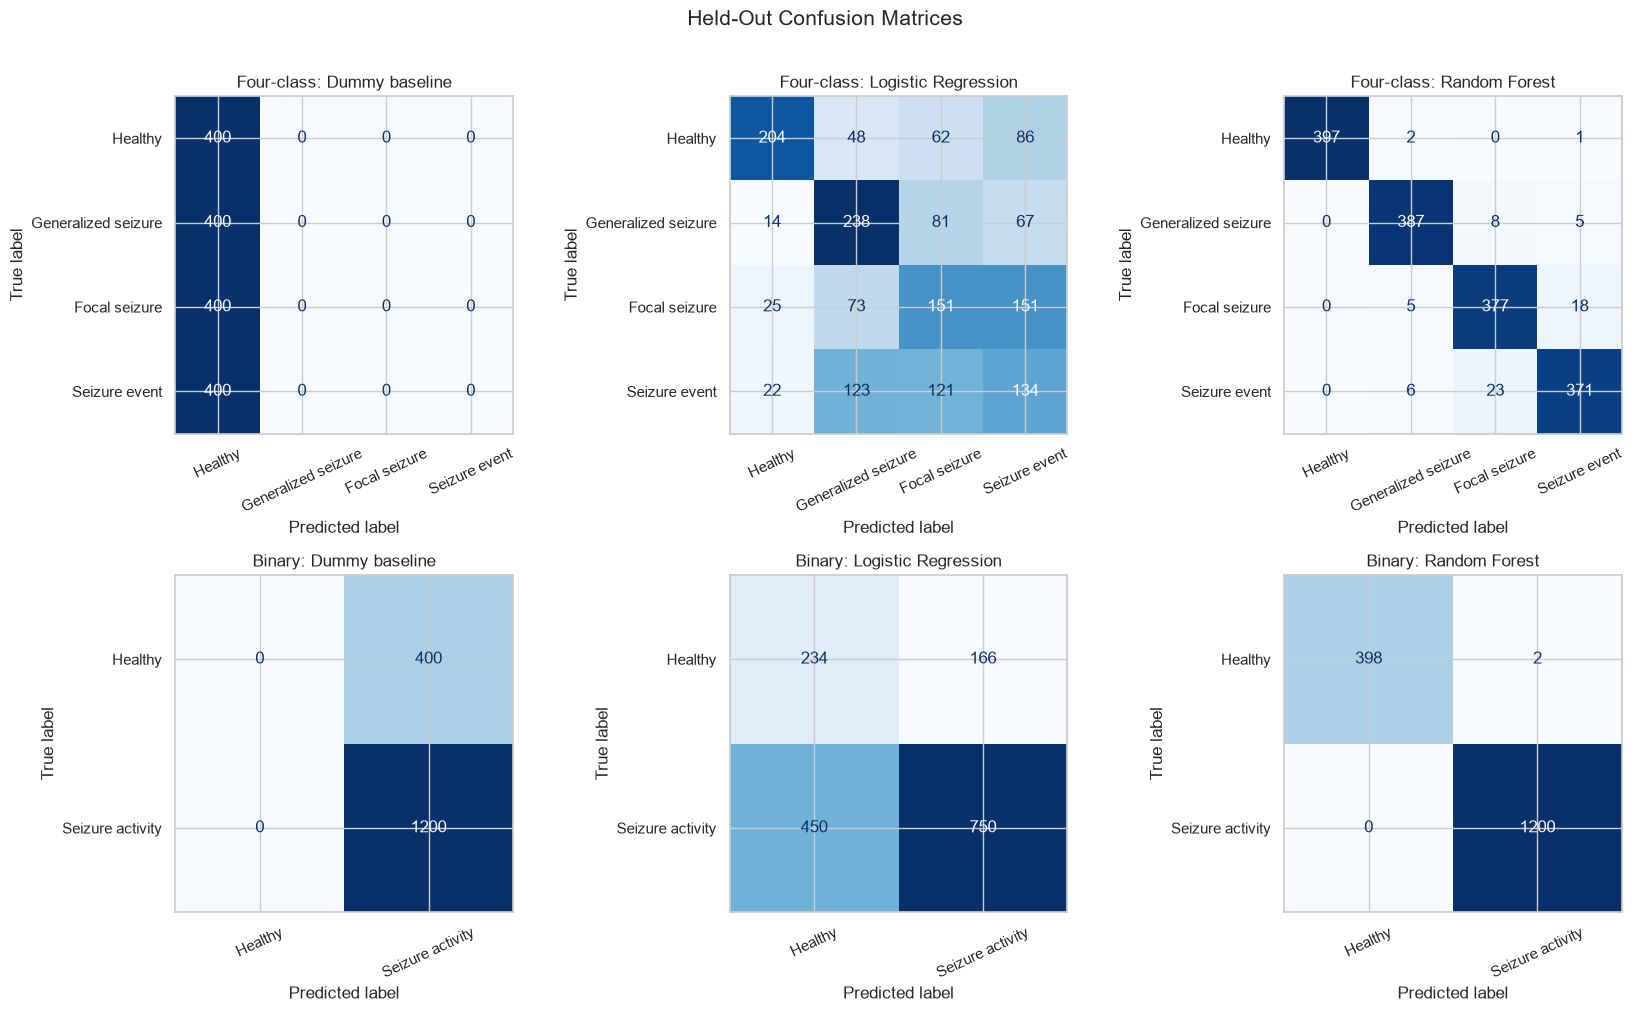

,precision,recall,f1-score,support
Four-class - Logistic Regression,,,,
Healthy,0.770,0.510,0.614,400.000
Generalized seizure,0.494,0.595,0.540,400.000
Focal seizure,0.364,0.378,0.371,400.000
Seizure event,0.306,0.335,0.320,400.000
accuracy,0.454,0.454,0.454,0.454
macro avg,0.483,0.454,0.461,1600.000
weighted avg,0.483,0.454,0.461,1600.000


,precision,recall,f1-score,support
Four-class - Random Forest,,,,
Healthy,1.000,0.992,0.996,400.000
Generalized seizure,0.968,0.968,0.968,400.000
Focal seizure,0.924,0.942,0.933,400.000
Seizure event,0.939,0.928,0.933,400.000
accuracy,0.958,0.958,0.958,0.958
macro avg,0.958,0.958,0.958,1600.000
weighted avg,0.958,0.958,0.958,1600.000


,precision,recall,f1-score,support
Binary - Logistic Regression,,,,
Healthy,0.342,0.585,0.432,400.000
Seizure activity,0.819,0.625,0.709,1200.000
accuracy,0.615,0.615,0.615,0.615
macro avg,0.580,0.605,0.570,1600.000
weighted avg,0.700,0.615,0.640,1600.000


,precision,recall,f1-score,support
Binary - Random Forest,,,,
Healthy,1.000,0.995,0.997,400.000
Seizure activity,0.998,1.000,0.999,1200.000
accuracy,0.999,0.999,0.999,0.999
macro avg,0.999,0.998,0.998,1600.000
weighted avg,0.999,0.999,0.999,1600.000


In [3]:
# Part III: Preliminary Results and Evaluation
#Extracts train and test sets once to avoid redundant indexing across tasks.
X_train = X.iloc[train_ids]
X_test = X.iloc[test_ids]

evaluation_rows = []
prediction_store = {}

for task_name, task in tasks.items():
    y_train = task["y"].iloc[train_ids]
    y_test = task["y"].iloc[test_ids]
    prediction_store[task_name] = {}

    for model_name, model in fitted_models[task_name].items():
        train_predictions = model.predict(X_train)
        test_predictions = model.predict(X_test)
        probabilities = model.predict_proba(X_test)

        if task_name == "Binary":
            roc_auc = roc_auc_score(y_test, probabilities[:, 1])
        else:
            roc_auc = roc_auc_score(
                y_test,
                probabilities,
                multi_class="ovr",
                average="macro",
            )

        prediction_store[task_name][model_name] = {
            "y_true": y_test,
            "predictions": test_predictions,
            "probabilities": probabilities,
        }
        evaluation_rows.append({
            "Target": task_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, test_predictions),
            "Balanced accuracy": balanced_accuracy_score(y_test, test_predictions),
            "Macro precision": precision_score(
                y_test, test_predictions, average="macro", zero_division=0
            ),
            "Macro recall": recall_score(
                y_test, test_predictions, average="macro", zero_division=0
            ),
            "Macro F1": f1_score(
                y_test, test_predictions, average="macro", zero_division=0
            ),
            "Weighted F1": f1_score(
                y_test, test_predictions, average="weighted", zero_division=0
            ),
            "ROC-AUC": roc_auc,
            "Train macro F1": f1_score(
                y_train, train_predictions, average="macro", zero_division=0
            ),
        })

evaluation_results = pd.DataFrame(evaluation_rows)
metric_columns = [
    "Accuracy", "Balanced accuracy", "Macro precision", "Macro recall",
    "Macro F1", "Weighted F1", "ROC-AUC", "Train macro F1",
]
display(evaluation_results.round({column: 3 for column in metric_columns}))

#Confusion matrices show the exact class pairs behind the summary metrics.
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for row_index, (task_name, task) in enumerate(tasks.items()):
    label_order = sorted(task["class_names"])
    display_names = [task["class_names"][label] for label in label_order]
    for column_index, model_name in enumerate(fitted_models[task_name]):
        stored = prediction_store[task_name][model_name]
        ConfusionMatrixDisplay.from_predictions(
            stored["y_true"],
            stored["predictions"],
            labels=label_order,
            display_labels=display_names,
            cmap="Blues",
            colorbar=False,
            ax=axes[row_index, column_index],
        )
        axes[row_index, column_index].set_title(f"{task_name}: {model_name}")
        axes[row_index, column_index].tick_params(axis="x", rotation=25)

fig.suptitle("Held-Out Confusion Matrices", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

#Shows class-specific reports for the two actual learning models.
#Use a parametrized approach to avoid hardcoded model names.
trained_model_names = [name for name in fitted_models[task_name].keys() if name != "Dummy baseline"]
for task_name, task in tasks.items():
    label_order = sorted(task["class_names"])
    target_names = [task["class_names"][label] for label in label_order]
    trained_model_names = [name for name in fitted_models[task_name].keys() if name != "Dummy baseline"]
    for model_name in trained_model_names:
        stored = prediction_store[task_name][model_name]
        report = classification_report(
            stored["y_true"],
            stored["predictions"],
            labels=label_order,
            target_names=target_names,
            zero_division=0,
            output_dict=True,
        )
        report_table = pd.DataFrame(report).T.round(3)
        report_table.index.name = f"{task_name} - {model_name}"
        display(report_table)

### What the metrics show

- **Accuracy** is the total proportion classified correctly. It is meaningful for the balanced four-class target but can overstate binary performance because 75% of that target is seizure activity.
- **Balanced accuracy** gives equal importance to every class by averaging class recalls. It is therefore a primary metric for comparing the two target formulations.
- **Macro precision, recall, and F1** give every class equal weight. Macro F1 summarizes the balance between false positives and false negatives without allowing the binary majority class to dominate.
- **Weighted F1** weights each class by its frequency. A much larger weighted than macro F1 would signal weaker performance on a smaller class.
- **ROC-AUC** evaluates probability ranking across thresholds. Binary AUC uses seizure activity as the positive class; four-class AUC uses macro one-versus-rest averaging.
- **Confusion matrices** show the direction and count of errors. They are especially important for checking whether focal seizures and seizure events remain difficult to distinguish, as suggested by EDA.

# Part IV: Model Comparison & Discussion (20 points)

Random Forest is currently the strongest model for both target formulations. For the balanced four-class task, it reached **0.956 macro F1**, **0.956 balanced accuracy**, and **0.997 macro one-vs.-rest ROC-AUC** on the held-out test set. For the binary task, it reached **0.997 macro F1**, **0.995 balanced accuracy**, and an ROC-AUC that rounded to **1.000**. These results also agree with the training-set cross-validation results, where Random Forest obtained 0.949 four-class macro F1 and 0.997 binary macro F1.

The four-class Random Forest made 70 errors out of 1,600 test observations. Its most frequent errors were between the two classes that overlapped most during EDA: 21 focal-seizure observations were predicted as seizure events, and 20 seizure-event observations were predicted as focal seizures. By contrast, the binary Random Forest made only four errors, all healthy observations classified as seizure activity; none of the 1,200 seizure observations were missed in this particular split. The binary task is easier because it does not require the model to distinguish among seizure subtypes.

Logistic Regression performed better than the no-skill baseline on class-sensitive metrics but remained much weaker than Random Forest. Its four-class test macro F1 was 0.461. Its binary accuracy was only 0.615, which is lower than the Dummy Classifier's 0.750 majority-class accuracy, but its balanced accuracy (0.605) and macro F1 (0.570) exceeded the Dummy Classifier's 0.500 and 0.429. This demonstrates why accuracy alone is misleading for the 75% seizure/25% healthy target. The Logistic Regression results suggest that simple linear decision boundaries do not capture the nonlinear patterns and interactions in these 16 predictors.

Some overfitting is visible in the four-class Random Forest: training macro F1 was approximately 1.000, compared with 0.949 during cross-validation and 0.956 on the test set. The validation standard deviation was only 0.009, so the preliminary result is stable across the five folds, but the training-validation gap still justifies later tuning. The binary Random Forest showed a much smaller gap. Computationally, Logistic Regression was faster and is easier to interpret through coefficients, while Random Forest took several seconds to fit and is less directly interpretable. However, its large performance advantage makes it the leading model for the next milestone.

Overall, class imbalance did not prevent Random Forest from performing well, but it strongly affected the meaning of the binary Dummy Classifier's accuracy. Balanced accuracy, macro F1, class-specific recall, and the confusion matrices should remain the primary evidence. The near-perfect binary result is provisional because the dataset does not include subject or recording identifiers; a row-level split may place observations from the same source in both training and test sets and therefore cannot establish performance on entirely new patients.

# Part V: Reflection & Next Steps (15 points)

### Reflection

The strongest part of this milestone is the experimental framework. Both target formulations use the same observations, the same stratified 80/20 split, and the same five-fold cross-validation process. Logistic Regression scaling occurs inside its pipeline, Random Forest uses the original channel values, and the held-out test set is not used during model development. The Dummy Classifier also provides a necessary reference point for judging whether the trained models learn more than class frequency.

The most surprising result was the size of Random Forest's advantage. It classified the binary target almost perfectly and also retained strong performance when the original four classes were preserved. This means the multiclass formulation should not be discarded simply because binary classification is easier. In contrast, Logistic Regression showed only moderate class separation, indicating that the dataset's useful structure is probably nonlinear rather than well represented by one linear boundary.

The main unresolved challenge is generalization. The Random Forest's nearly perfect training scores and extremely high row-level test results may reflect true class structure, but they may also be optimistic because subject identifiers are unavailable. The present experiment evaluates unseen rows from the CSV, not unseen patients. Another remaining challenge is understanding which channels and decision patterns drive the Random Forest without treating correlated feature importance values as direct physiological evidence.

### Next steps

1. Use repeated stratified cross-validation on the training set to confirm that the model ranking and binary-versus-multiclass difference are stable across more splits.
2. Tune a limited set of Random Forest controls, including maximum tree depth, minimum leaf size, number of trees, and number of features considered at each split. Logistic Regression regularization strength can be tuned as a secondary linear comparison.
3. Keep all model selection and tuning inside cross-validation, then evaluate the selected final pipelines once on the unchanged test set.
4. Perform class-specific error analysis, especially for focal seizures versus seizure events, and examine permutation importance to estimate which channels contribute to prediction.
5. If subject or recording identifiers can be recovered, replace the row-level split with a group-based evaluation. Without those identifiers, final conclusions must remain limited to observation-level classification.
6. Compare the final binary and four-class models using macro F1, balanced accuracy, class recall, confusion matrices, ROC-AUC, runtime, and interpretability. Temporal or frequency-domain features should not be created unless the dataset documentation confirms a valid time sequence.

At this stage, Random Forest is the leading model, while Logistic Regression remains a useful interpretable benchmark. The project has established a reliable preliminary pipeline, but the final milestone should focus on validating the framework and explaining model behavior rather than maximizing a single test score.